In [73]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats

In [75]:
start_date = "2016-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

vix_df = yf.download("^VIX", start=start_date, end=end_date, progress=False)
spx_df = yf.download("^GSPC", start=start_date, end=end_date, progress=False)

C:\Users\malav\AppData\Local\Temp\ipykernel_48528\3788011013.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix_df = yf.download("^VIX", start=start_date, end=end_date, progress=False)
C:\Users\malav\AppData\Local\Temp\ipykernel_48528\3788011013.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spx_df = yf.download("^GSPC", start=start_date, end=end_date, progress=False)


In [77]:
vix = vix_df.squeeze()
if isinstance(vix, pd.DataFrame):
    vix = vix.iloc[:, 0]
vix.name = "VIX"

spx_close = spx_df.squeeze()
if isinstance(spx_close, pd.DataFrame):
    spx_close = spx_close.iloc[:, 0]
spx_close.name = "SPX"

spx_ret = spx_close.pct_change().rename("SPX_ret")

data = pd.concat([vix, spx_ret], axis=1).dropna()

In [79]:

window = 5
threshold = 25

data["rolling_max"] = data["VIX"].rolling(window=2*window+1, center=True).max()
data["is_peak"] = (data["VIX"] == data["rolling_max"]) & (data["VIX"] >= threshold)
vix_peaks = data.index[data["is_peak"]]

print(f"Detected {len(vix_peaks)} VIX peaks above {threshold} from {start_date} to {end_date}:\n")

peaks_table = data.loc[vix_peaks, ["VIX"]].sort_index(ascending=False)
print(peaks_table.head(15))

Detected 40 VIX peaks above 25 from 2016-01-01 to 2025-12-06:

                  VIX
Date                 
2025-11-20  26.420000
2025-10-16  25.309999
2025-04-08  52.330002
2025-03-10  27.860001
2024-12-18  27.620001
2024-08-05  38.570000
2023-03-13  26.520000
2022-12-12  25.000000
2022-11-09  26.090000
2022-10-11  33.630001
2022-09-27  32.599998
2022-09-13  27.270000
2022-06-13  34.020000
2022-05-09  34.750000
2022-04-26  33.520000


In [81]:
pre_days = 10
post_days = 10
event_matrix = []

for peak in vix_peaks:
    window_data = data.loc[peak - pd.Timedelta(days=pre_days*2):
                           peak + pd.Timedelta(days=post_days*2)]
    if len(window_data) < pre_days + post_days + 1:
        continue
    window_data = window_data.iloc[-(pre_days + post_days + 1):]
    event_matrix.append(window_data["SPX_ret"].values)
event_matrix

[array([ 0.00085327,  0.0078028 , -0.02496545,  0.01669591, -0.0215991 ,
         0.00053182, -0.01169386,  0.00519544,  0.0202837 , -0.01563798,
         0.01414434, -0.01086348,  0.00552858,  0.02476022, -0.00044324,
        -0.01874309,  0.00499204,  0.00152673, -0.01848125, -0.01415394,
        -0.00066362]),
 array([-1.87430908e-02,  4.99203893e-03,  1.52673256e-03, -1.84812463e-02,
        -1.41539357e-02, -6.63620353e-04, -1.88950277e-04, -1.23011618e-02,
         1.95180496e-02,  1.65166541e-02,  1.64804392e-02, -4.66571371e-03,
        -2.60329429e-05,  1.44541972e-02, -1.24543719e-02,  4.43978681e-03,
         1.13482754e-02, -1.87011448e-03, -8.12097634e-03,  2.38687918e-02,
         4.09430874e-03]),
 array([-0.00184071,  0.00313299, -0.00325797,  0.00580819,  0.00271206,
        -0.00165156,  0.01336408, -0.0359198 , -0.0180965 ,  0.01777017,
         0.01703267,  0.01356504,  0.0019486 , -0.00684748,  0.00535296,
        -0.00087158,  0.01525335,  0.00340862,  0.00700929,

In [83]:

event_matrix = np.vstack(event_matrix)
AAR = event_matrix.mean(axis=0)
CAR = AAR.cumsum()
days = np.arange(-pre_days, post_days+1)

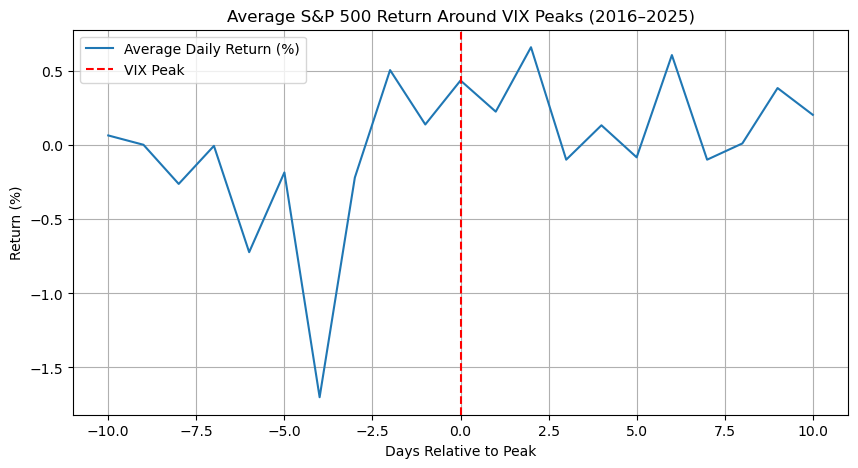

In [85]:
plt.figure(figsize=(10,5))
plt.plot(days, AAR*100, label="Average Daily Return (%)")
plt.axvline(0, color='red', linestyle='--', label='VIX Peak')
plt.title("Average S&P 500 Return Around VIX Peaks (2016–2025)")
plt.xlabel("Days Relative to Peak")
plt.ylabel("Return (%)")
plt.legend(); plt.grid(True); plt.show()

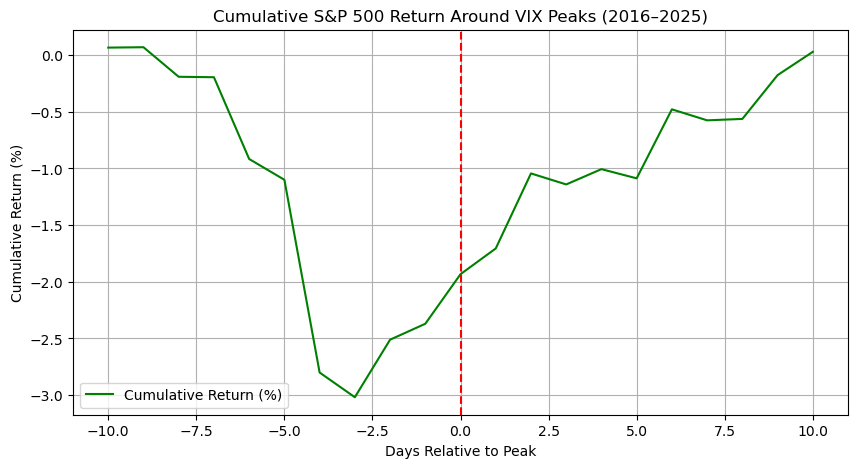

In [87]:
plt.figure(figsize=(10,5))
plt.plot(days, CAR*100, color='green', label="Cumulative Return (%)")
plt.axvline(0, color='red', linestyle='--')
plt.title("Cumulative S&P 500 Return Around VIX Peaks (2016–2025)")
plt.xlabel("Days Relative to Peak")
plt.ylabel("Cumulative Return (%)")
plt.legend(); plt.grid(True); plt.show()

In [89]:
pre_mean = AAR[days < 0].mean()
post_mean = AAR[days > 0].mean()
print(f"\nAvg daily return BEFORE peaks: {pre_mean*100:.3f}%")
print(f"Avg daily return AFTER peaks:  {post_mean*100:.3f}%")


Avg daily return BEFORE peaks: -0.237%
Avg daily return AFTER peaks:  0.196%


In [19]:
sp500 = pd.read_csv(
    "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/master/data/constituents.csv"
)


In [51]:

def event_window(series, peaks, pre=10, post=10):
    mats = []
    for peak in peaks:
        window = series.loc[peak - pd.Timedelta(days=pre*2): peak + pd.Timedelta(days=post*2)]
        if len(window) >= pre + post + 1:
            mats.append(window.iloc[-(pre+post+1):].values)
    if not mats:
        return None, None, np.arange(-pre, post+1)
    mats = np.vstack(mats)
    AAR = mats.mean(axis=0)
    CAR = AAR.cumsum()
    return AAR, CAR, np.arange(-pre, post+1)

In [53]:
sp500["Symbol"] = sp500["Symbol"].str.replace(".", "-", regex=False)

In [55]:
# Drop known bad / delisted tickers that yfinance chokes on
bad_tickers = ["WBA"]
tickers = [t for t in sp500["Symbol"].unique().tolist() if t not in bad_tickers]
print(f"\nLoaded {len(tickers)} S&P500 tickers (after dropping bad ones)\n")

raw = yf.download(tickers, start=start_date, end=end_date, progress=False)

if raw.empty:
    raise RuntimeError("yf.download returned no data for S&P 500 tickers.")

# robust price extraction for MultiIndex vs normal DataFrame
if isinstance(raw.columns, pd.MultiIndex):
    lvl0 = raw.columns.get_level_values(0)
    if "Adj Close" in lvl0:
        prices = raw.xs("Adj Close", axis=1, level=0)
    elif "Close" in lvl0:
        prices = raw.xs("Close", axis=1, level=0)
    else:
        raise KeyError("Neither 'Adj Close' nor 'Close' found in MultiIndex columns.")
else:
    if "Adj Close" in raw.columns:
        prices = raw["Adj Close"]
    elif "Close" in raw.columns:
        prices = raw["Close"]
    else:
        raise KeyError("Neither 'Adj Close' nor 'Close' column found.")



Loaded 502 S&P500 tickers (after dropping bad ones)



C:\Users\malav\AppData\Local\Temp\ipykernel_48528\1616662275.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(tickers, start=start_date, end=end_date, progress=False)


In [57]:

# drop tickers with no data at all
prices = prices.dropna(axis=1, how="all")

# returns: don't forward-fill, just raw pct change and drop all-NaN rows
returns = prices.pct_change(fill_method=None).dropna(how="all")

print(f"Returns shape: {returns.shape}")
print(f"First 5 return columns: {list(returns.columns[:5])}")

print(f"Returns shape: {returns.shape}")
print(f"First 5 return columns: {list(returns.columns[:5])}")

Returns shape: (2496, 502)
First 5 return columns: ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT']
Returns shape: (2496, 502)
First 5 return columns: ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT']


In [59]:
#FUNDAMENTALS (SIZE + SECTOR)
# Compute realized volatility for each stock
volatility = returns.std().sort_values()

# Split by median volatility -> low-vol ≈ large-cap, high-vol ≈ small-cap
median_vol = volatility.median()
large_caps = volatility[volatility <= median_vol].index
small_caps = volatility[volatility > median_vol].index

print(f"Large-cap (low-vol) count: {len(large_caps)}")
print(f"Small-cap (high-vol) count: {len(small_caps)}")

Large-cap (low-vol) count: 251
Small-cap (high-vol) count: 251


In [61]:
#SECTOR INFO 
sector_info = {}
for t in returns.columns:
    try:
        tkr = yf.Ticker(t)
        sector_info[t] = tkr.info.get("sector", "Unknown")
    except:
        sector_info[t] = "Unknown"

meta = pd.DataFrame({"sector": sector_info})
if len(large_caps) == 0 or len(small_caps) == 0:
    raise RuntimeError("Could not form size portfolios — not enough usable tickers in 'returns'.")

In [62]:

port_large = returns[large_caps].mean(axis=1)
port_small = returns[small_caps].mean(axis=1)

sector_ports = {}
for sector in meta["sector"].dropna().unique():
    tickers_in_sector = meta[meta["sector"] == sector].index
    tickers_in_sector = [t for t in tickers_in_sector if t in returns.columns]
    if len(tickers_in_sector) > 5:
        sector_ports[sector] = returns[tickers_in_sector].mean(axis=1)


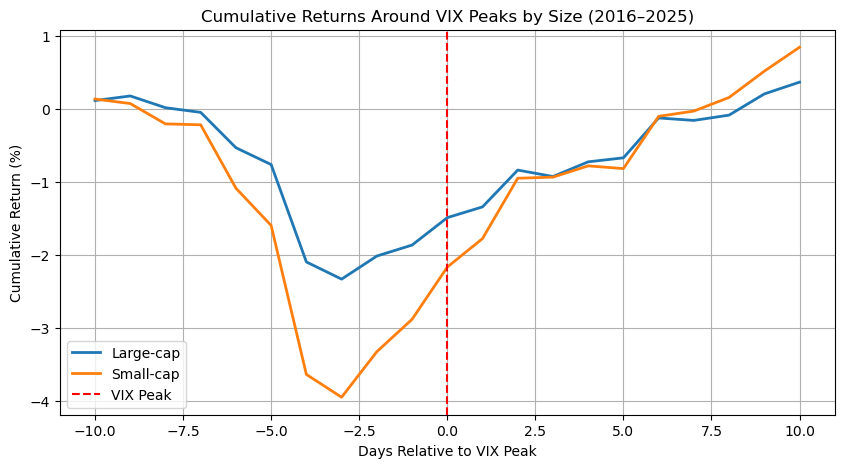

In [63]:
#  EVENT STUDY: SIZE
AAR_large, CAR_large, days = event_window(port_large, vix_peaks)
AAR_small, CAR_small, _ = event_window(port_small, vix_peaks)

plt.figure(figsize=(10,5))
plt.plot(days, CAR_large*100, label="Large-cap", lw=2)
plt.plot(days, CAR_small*100, label="Small-cap", lw=2)
plt.axvline(0, color="red", linestyle="--", label="VIX Peak")
plt.title("Cumulative Returns Around VIX Peaks by Size (2016–2025)")
plt.xlabel("Days Relative to VIX Peak")
plt.ylabel("Cumulative Return (%)")
plt.legend(); plt.grid(True); plt.show()

In [67]:
pre_large = AAR_large[days < 0].mean(); post_large = AAR_large[days > 0].mean()
pre_small = AAR_small[days < 0].mean(); post_small = AAR_small[days > 0].mean()

print(f"\nLarge caps: pre {pre_large*100:.3f}%, post {post_large*100:.3f}%")
print(f"Small caps: pre {pre_small*100:.3f}%, post {post_small*100:.3f}%")

if post_small > post_large:
    print("→ Small-caps rebound more strongly after VIX peaks (supports overreaction hypothesis).")
else:
    print("→ No clear size asymmetry in rebound.")


Large caps: pre -0.187%, post 0.186%
Small caps: pre -0.288%, post 0.301%
→ Small-caps rebound more strongly after VIX peaks (supports overreaction hypothesis).


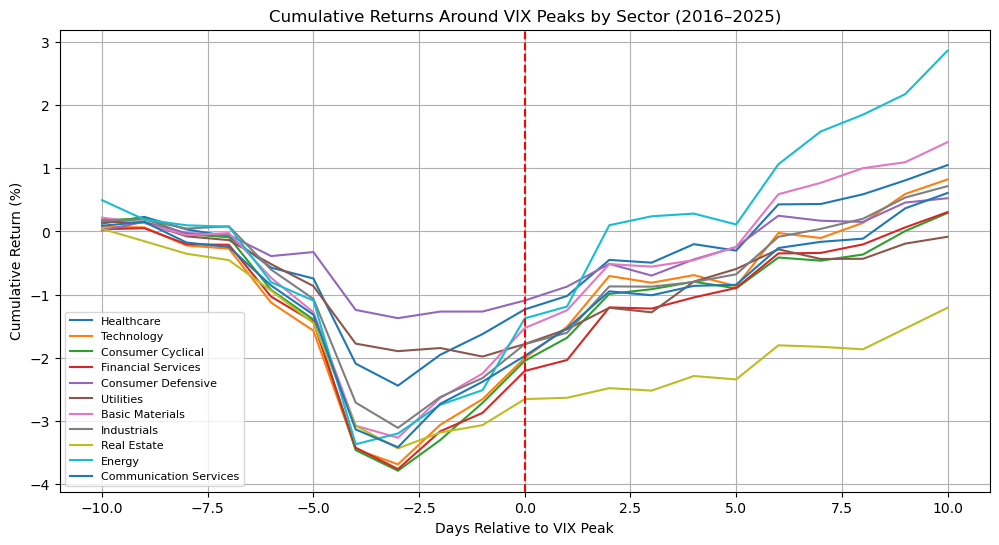

In [69]:
#  EVENT STUDY: SECTORS
plt.figure(figsize=(12,6))
for sector, port in sector_ports.items():
    _, CAR_sector, _ = event_window(port, vix_peaks)
    if CAR_sector is not None:
        plt.plot(days, CAR_sector*100, lw=1.5, label=sector)
plt.axvline(0, color='red', linestyle='--')
plt.title("Cumulative Returns Around VIX Peaks by Sector (2016–2025)")
plt.xlabel("Days Relative to VIX Peak")
plt.ylabel("Cumulative Return (%)")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

In [71]:
#  SECTOR SUMMARY TABLE
sector_summary = []
for sector, port in sector_ports.items():
    AAR_sector, _, _ = event_window(port, vix_peaks)
    if AAR_sector is not None:
        pre = AAR_sector[days < 0].mean()
        post = AAR_sector[days > 0].mean()
        sector_summary.append((sector, pre, post, post - pre))
sector_summary = pd.DataFrame(sector_summary, columns=["Sector", "Pre", "Post", "PostMinusPre"])
print("\nAverage sector reactions (daily returns):")
print(sector_summary.sort_values("PostMinusPre", ascending=False).head(10))


Average sector reactions (daily returns):
                    Sector       Pre      Post  PostMinusPre
9                   Energy -0.002515  0.004242      0.006757
1               Technology -0.002658  0.002830      0.005488
3       Financial Services -0.002876  0.002516      0.005392
6          Basic Materials -0.002252  0.002945      0.005197
2        Consumer Cyclical -0.002717  0.002342      0.005059
10  Communication Services -0.002381  0.002582      0.004964
7              Industrials -0.002324  0.002504      0.004828
8              Real Estate -0.003069  0.001447      0.004516
0               Healthcare -0.001627  0.002287      0.003913
5                Utilities -0.001983  0.001700      0.003683
